# Modélisation

### Imports et chargement

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

print("ok")

ModuleNotFoundError: No module named 'xgboost'

In [17]:
# Chargement des données
with open("datas/app_train_final.pkl", "rb") as f:
    app_train = pickle.load(f)
with open("datas/app_test_final.pkl", "rb") as f:
    app_test = pickle.load(f)

TARGET   = 'TARGET'
ID       = 'SK_ID_CURR'
FEATURES = [c for c in app_train.columns if c not in [TARGET, ID]]

X = app_train[FEATURES]
y = app_train[TARGET]

print(f"X shape : {X.shape}")
print(f"Taux de défaut : {y.mean()*100:.2f}%")
print(f"Valeurs manquantes : {X.isnull().sum().sum()}")

X shape : (307507, 207)
Taux de défaut : 8.07%
Valeurs manquantes : 0


In [18]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("credit-scoring-2")

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Expérience  : credit-scoring")

# Test de connexion
with mlflow.start_run(run_name="test_connexion"):
    mlflow.log_param("test", True)
    mlflow.log_metric("test_metric", 1.0)
    print("MLFlow : http://localhost:5000")

Tracking URI : sqlite:///mlflow.db
Expérience  : credit-scoring
MLFlow : http://localhost:5000


In [19]:
# Sauvegarde du dataset pour traçabilité MLFlow
dataset_path = "datas/home_credit_train.parquet"
app_train[FEATURES + [TARGET]].to_parquet(dataset_path, index=False)

# Définition avec source fichier explicite
dataset = mlflow.data.from_pandas(
    app_train[FEATURES + [TARGET]],
    source=dataset_path,
    name="home_credit_train",
    targets=TARGET
)
print(f"✓ Dataset défini : {dataset.name}")
print(f"  Source    : {dataset_path}")
print(f"  Lignes    : {len(app_train)}")
print(f"  Features  : {len(FEATURES)}")

✓ Dataset défini : home_credit_train
  Source    : datas/home_credit_train.parquet
  Lignes    : 307507
  Features  : 207


In [20]:
def business_cost(y_true, y_proba, threshold=0.5, fn_cost=10, fp_cost=1):
    """
    Calcule le coût métier normalisé.

    FN (mauvais client accepté) : perte en capital → fn_cost = 10
    FP (bon client refusé)      : manque à gagner  → fp_cost = 1

    Retourne un coût normalisé par le nombre de clients.
    Plus le score est bas, meilleur est le modèle.
    """
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return (fn * fn_cost + fp * fp_cost) / len(y_true)

In [21]:
from sklearn.neural_network import MLPClassifier

models = {
    "LogisticRegression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
        random_state=42,
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        random_state=42,
        eval_metric='auc',
        n_jobs=-1,
        verbosity=0
    ),
}

print(f"{len(models)} modèles définis.")
for name, model in models.items():
    print(f"  {name}")

5 modèles définis.
  LogisticRegression
  RandomForest
  MLP
  LightGBM
  XGBoost



  LogisticRegression
  Fold 1 | AUC=0.6451 | Coût=0.6733 | Acc=0.6648
  Fold 2 | AUC=0.6411 | Coût=0.6774 | Acc=0.6678
  Fold 3 | AUC=0.6492 | Coût=0.6635 | Acc=0.6709
  Fold 4 | AUC=0.6467 | Coût=0.6712 | Acc=0.6629
  Fold 5 | AUC=0.6474 | Coût=0.6690 | Acc=0.6683


2026/06/04 15:52:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 15:52:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


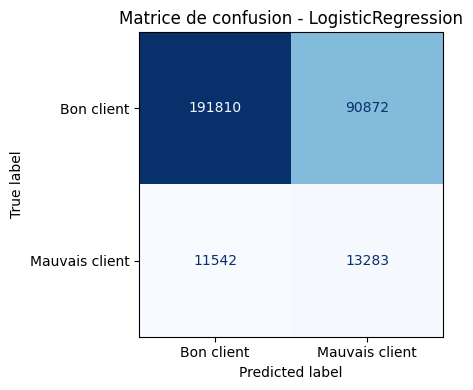

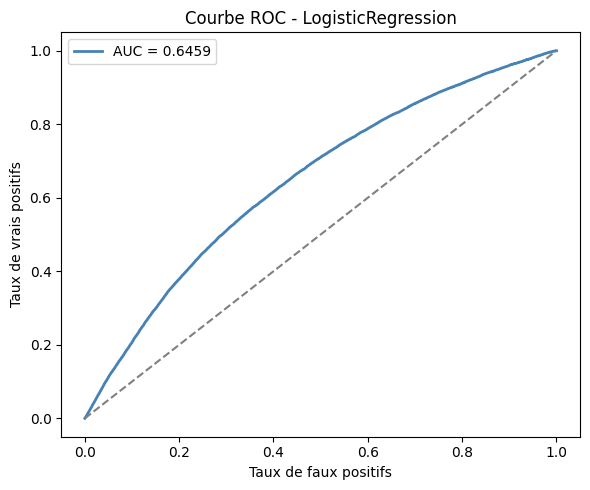


  → AUC       : 0.6459 ± 0.0027
  → Coût      : 0.6709
  → Accuracy  : 0.6670
  → Precision : 0.1275
  → Recall    : 0.5351

  RandomForest
  Fold 1 | AUC=0.7518 | Coût=0.5415 | Acc=0.7045
  Fold 2 | AUC=0.7594 | Coût=0.5254 | Acc=0.7137
  Fold 3 | AUC=0.7536 | Coût=0.5408 | Acc=0.7083
  Fold 4 | AUC=0.7592 | Coût=0.5291 | Acc=0.7103
  Fold 5 | AUC=0.7487 | Coût=0.5481 | Acc=0.7097


2026/06/04 15:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 15:54:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


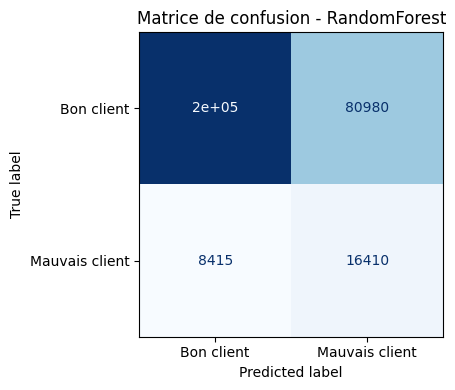

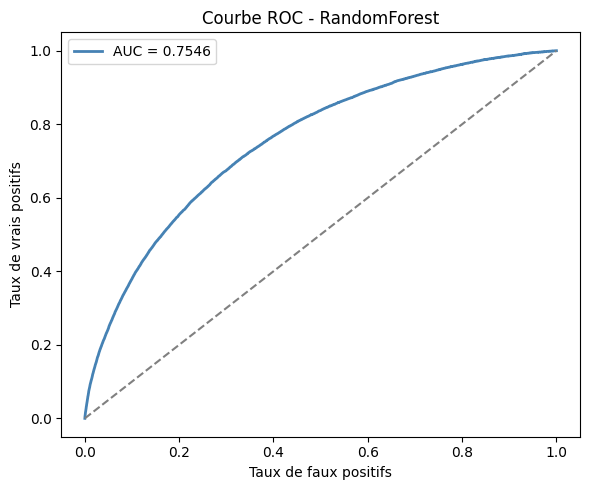


  → AUC       : 0.7546 ± 0.0042
  → Coût      : 0.5370
  → Accuracy  : 0.7093
  → Precision : 0.1685
  → Recall    : 0.6610

  MLP
  Fold 1 | AUC=0.5738 | Coût=0.7441 | Acc=0.7304
  Fold 2 | AUC=0.5601 | Coût=0.7911 | Acc=0.3871
  Fold 3 | AUC=0.5774 | Coût=0.7623 | Acc=0.6985
  Fold 4 | AUC=0.5507 | Coût=0.7688 | Acc=0.7140
  Fold 5 | AUC=0.5947 | Coût=0.7270 | Acc=0.8048


2026/06/04 16:02:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 16:02:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


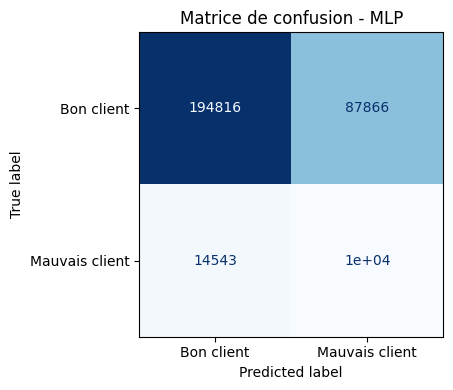

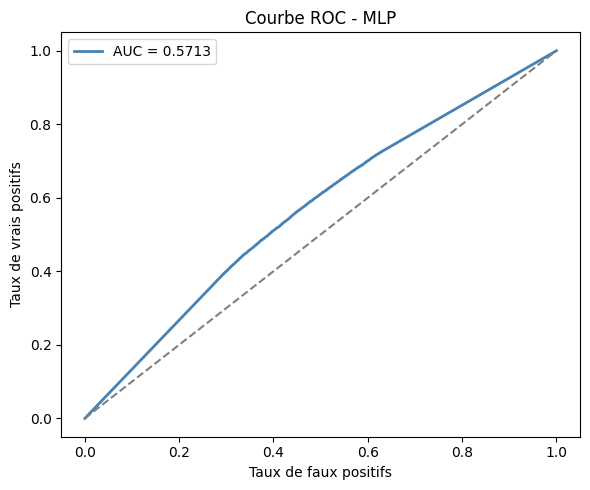


  → AUC       : 0.5713 ± 0.0151
  → Coût      : 0.7587
  → Accuracy  : 0.6670
  → Precision : 0.1109
  → Recall    : 0.4142

  LightGBM
  Fold 1 | AUC=0.7788 | Coût=0.4980 | Acc=0.7475
  Fold 2 | AUC=0.7872 | Coût=0.4900 | Acc=0.7481
  Fold 3 | AUC=0.7811 | Coût=0.4964 | Acc=0.7442
  Fold 4 | AUC=0.7867 | Coût=0.4879 | Acc=0.7471
  Fold 5 | AUC=0.7805 | Coût=0.5021 | Acc=0.7467


2026/06/04 16:04:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 16:04:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


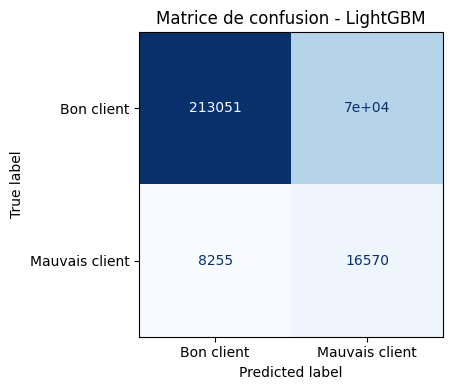

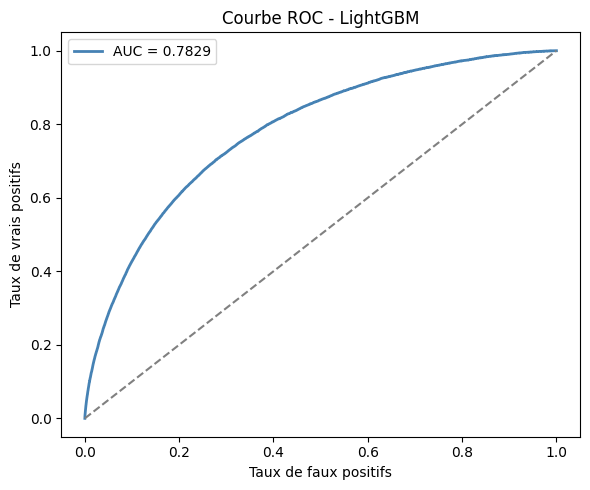


  → AUC       : 0.7829 ± 0.0035
  → Coût      : 0.4949
  → Accuracy  : 0.7467
  → Precision : 0.1922
  → Recall    : 0.6675

  XGBoost
  Fold 1 | AUC=0.7779 | Coût=0.4967 | Acc=0.7468
  Fold 2 | AUC=0.7852 | Coût=0.4901 | Acc=0.7490
  Fold 3 | AUC=0.7820 | Coût=0.4942 | Acc=0.7458
  Fold 4 | AUC=0.7858 | Coût=0.4876 | Acc=0.7494
  Fold 5 | AUC=0.7791 | Coût=0.5001 | Acc=0.7487


2026/06/04 16:05:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 16:05:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


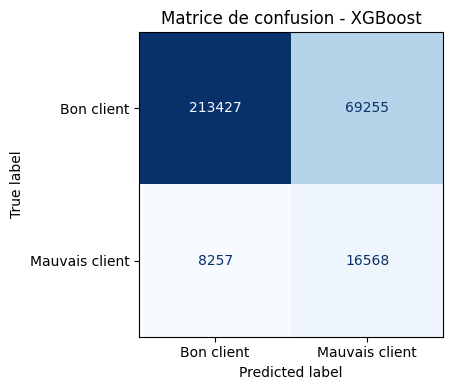

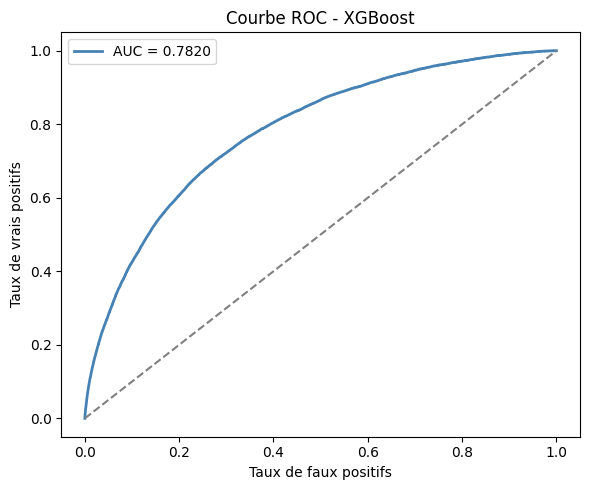


  → AUC       : 0.7820 ± 0.0032
  → Coût      : 0.4937
  → Accuracy  : 0.7479
  → Precision : 0.1931
  → Recall    : 0.6674


In [23]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve,
                             precision_score, recall_score,
                             RocCurveDisplay)
from sklearn.utils.class_weight import compute_sample_weight

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    auc_scores, cost_scores, accuracy_scores = [], [], []
    precision_scores, recall_scores = [], []
    all_y_val, all_proba = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Gestion du déséquilibre : class_weight pour les modèles compatibles,
        if name == 'MLP':
            sample_weights = compute_sample_weight('balanced', y_tr)
            model.fit(X_tr, y_tr, sample_weight=sample_weights)
        else:
            model.fit(X_tr, y_tr)

        proba  = model.predict_proba(X_val)[:, 1]
        y_pred = (proba >= 0.5).astype(int)

        auc_scores.append(roc_auc_score(y_val, proba))
        cost_scores.append(business_cost(y_val, proba, threshold=0.5))
        accuracy_scores.append(accuracy_score(y_val, y_pred))
        precision_scores.append(precision_score(y_val, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_val, y_pred, zero_division=0))

        # Accumulation pour les courbes globales
        all_y_val.extend(y_val.tolist())
        all_proba.extend(proba.tolist())

        print(f"  Fold {fold+1} | AUC={auc_scores[-1]:.4f} | "
              f"Coût={cost_scores[-1]:.4f} | Acc={accuracy_scores[-1]:.4f}")

    all_y_val = np.array(all_y_val)
    all_proba = np.array(all_proba)
    all_pred  = (all_proba >= 0.5).astype(int)

    mean_auc       = np.mean(auc_scores)
    std_auc        = np.std(auc_scores)
    mean_cost      = np.mean(cost_scores)
    mean_accuracy  = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall    = np.mean(recall_scores)

    results[name] = {
        'auc': mean_auc,
        'std_auc': std_auc,
        'cost': mean_cost,
        'accuracy': mean_accuracy,
        'model': model
    }

    # === Matrice de confusion (sur toutes les prédictions CV) ===
    cm  = confusion_matrix(all_y_val, all_pred)
    fig_cm, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Bon client', 'Mauvais client']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"Matrice de confusion - {name}")
    plt.tight_layout()

    # === Courbe ROC (sur toutes les prédictions CV) ===
    fpr, tpr, _ = roc_curve(all_y_val, all_proba)
    fig_roc, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color='steelblue', lw=2,
            label=f'AUC = {mean_auc:.4f}')
    ax.plot([0,1], [0,1], color='gray', linestyle='--')
    ax.set_xlabel("Taux de faux positifs")
    ax.set_ylabel("Taux de vrais positifs")
    ax.set_title(f"Courbe ROC - {name}")
    ax.legend()
    plt.tight_layout()

    # === Logging MLFlow ===
    with mlflow.start_run(run_name=f"{name}_baseline"):
        mlflow.set_tag("model_type", name)
        mlflow.set_tag("phase", "baseline")
        mlflow.set_tag("cv_folds", 5)
        mlflow.log_params(model.get_params())
        mlflow.log_metric("mean_auc_cv",       mean_auc)
        mlflow.log_metric("std_auc_cv",        std_auc)
        mlflow.log_metric("mean_cost_cv",      mean_cost)
        mlflow.log_metric("mean_accuracy_cv",  mean_accuracy)
        mlflow.log_metric("mean_precision_cv", mean_precision)
        mlflow.log_metric("mean_recall_cv",    mean_recall)
        mlflow.log_figure(fig_cm,  f"confusion_matrix_{name}.png")
        mlflow.log_figure(fig_roc, f"roc_curve_{name}.png")
        mlflow.log_input(dataset, context="training")
        mlflow.sklearn.log_model(model, "model")

    plt.show()

    print(f"\n  → AUC       : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  → Coût      : {mean_cost:.4f}")
    print(f"  → Accuracy  : {mean_accuracy:.4f}")
    print(f"  → Precision : {mean_precision:.4f}")
    print(f"  → Recall    : {mean_recall:.4f}")

,Modèle,AUC moyen,AUC std,Coût métier
0,LightGBM,0.782871,0.003455,0.494886
1,XGBoost,0.781985,0.003164,0.493729
2,RandomForest,0.754560,0.004192,0.536996
3,LogisticRegression,0.645908,0.002742,0.670853
4,MLP,0.571336,0.015110,0.758669


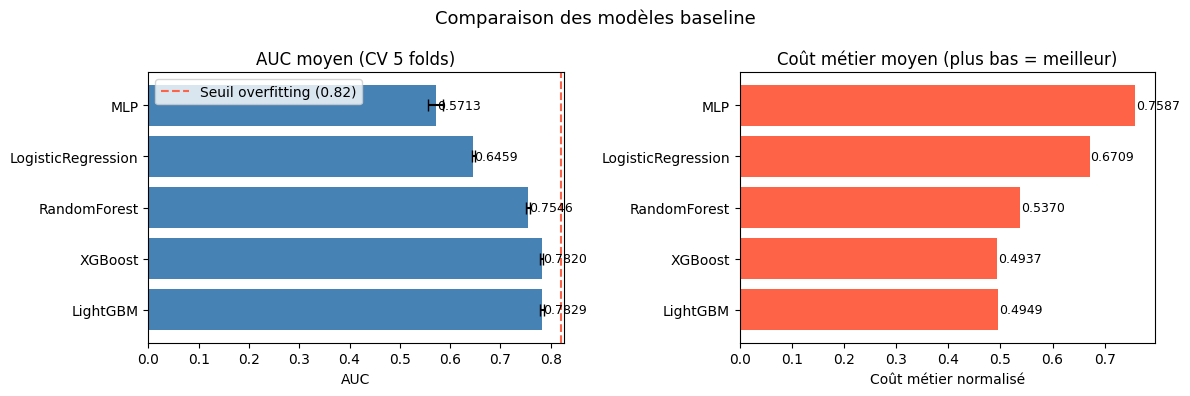

In [24]:
comparison = pd.DataFrame({
    'Modèle': list(results.keys()),
    'AUC moyen': [v['auc'] for v in results.values()],
    'AUC std': [v['std_auc'] for v in results.values()],
    'Coût métier': [v['cost'] for v in results.values()],
}).sort_values('AUC moyen', ascending=False).reset_index(drop=True)

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC
axes[0].barh(comparison['Modèle'], comparison['AUC moyen'],
             xerr=comparison['AUC std'], color='steelblue',
             align='center', capsize=4)
axes[0].set_title("AUC moyen (CV 5 folds)")
axes[0].set_xlabel("AUC")
axes[0].axvline(0.82, color='tomato', linestyle='--', label='Seuil overfitting (0.82)')
axes[0].legend()
for i, v in enumerate(comparison['AUC moyen']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Coût métier
axes[1].barh(comparison['Modèle'], comparison['Coût métier'],
             color='tomato', align='center')
axes[1].set_title("Coût métier moyen (plus bas = meilleur)")
axes[1].set_xlabel("Coût métier normalisé")
for i, v in enumerate(comparison['Coût métier']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle("Comparaison des modèles baseline", fontsize=13)
plt.tight_layout()
plt.show()

Résultats clairs. LightGBM et XGBoost sont quasi ex-aequo. XGBoost gagne sur le coût métier (0.4937 vs 0.4949), LightGBM gagne sur l'AUC (0.7829 vs 0.7820). Les deux sont valides.

On choisit LightGBM pour l'optimisation : c'est le modèle de référence de jsaguiar, il est plus rapide à entraîner, et l'écart de coût avec XGBoost est négligeable (0.0012). On l'optimisera avec Optuna qui est plus efficace que GridSearchCV sur autant de paramètres.

In [25]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = LGBMClassifier(**params)
    skf   = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    costs = []

    for tr_idx, val_idx in skf.split(X, y):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        costs.append(business_cost(y.iloc[val_idx], proba, threshold=0.5))

    return np.mean(costs)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMeilleur coût métier : {study.best_value:.4f}")
print(f"Meilleurs paramètres :\n{study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Meilleur coût métier : 0.4912
Meilleurs paramètres :
{'n_estimators': 681, 'learning_rate': 0.039776609130093434, 'num_leaves': 50, 'max_depth': 5, 'min_child_samples': 81, 'subsample': 0.9165984948931442, 'colsample_bytree': 0.6782947639720086, 'reg_alpha': 0.07485468520956352, 'reg_lambda': 0.252156867122648}


In [26]:
best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42
best_params['n_jobs']       = -1
best_params['verbose']      = -1

best_model = LGBMClassifier(**best_params)

# CV finale sur 5 folds pour évaluation robuste
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores  = []
cost_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = best_model.predict_proba(X.iloc[val_idx])[:, 1]
    auc_scores.append(roc_auc_score(y.iloc[val_idx], proba))
    cost_scores.append(business_cost(y.iloc[val_idx], proba))
    print(f"Fold {fold+1} | AUC={auc_scores[-1]:.4f} | Coût={cost_scores[-1]:.4f}")

mean_auc  = np.mean(auc_scores)
mean_cost = np.mean(cost_scores)

print(f"\n→ AUC  : {mean_auc:.4f} ± {np.std(auc_scores):.4f}")
print(f"→ Coût : {mean_cost:.4f}")

# Entraînement sur tout le dataset pour le modèle final
best_model.fit(X, y)

# Logging MLFlow
with mlflow.start_run(run_name="LightGBM_optimized") as run:
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("phase", "optimized")
    mlflow.set_tag("optimizer", "optuna_50_trials")
    mlflow.log_params(best_params)
    mlflow.log_metric("mean_auc_cv",  mean_auc)
    mlflow.log_metric("std_auc_cv",   np.std(auc_scores))
    mlflow.log_metric("mean_cost_cv", mean_cost)
    mlflow.lightgbm.log_model(best_model, "model")
    run_id = run.info.run_id

print(f"\n✓ Run loggé : {run_id}")

Fold 1 | AUC=0.7811 | Coût=0.4955
Fold 2 | AUC=0.7900 | Coût=0.4863
Fold 3 | AUC=0.7846 | Coût=0.4918
Fold 4 | AUC=0.7876 | Coût=0.4864
Fold 5 | AUC=0.7825 | Coût=0.4954

→ AUC  : 0.7852 ± 0.0033
→ Coût : 0.4911


2026/06/04 19:51:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 19:51:16 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✓ Run loggé : a873448802224d48ab0e3b34c6bf7b22


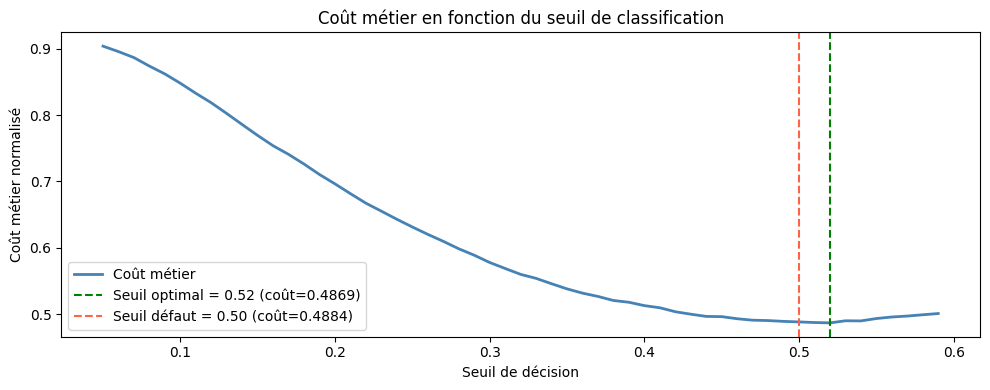

AUC (indépendant du seuil) : 0.7864
Coût à seuil 0.50          : 0.4884
Coût au seuil optimal      : 0.4869
Seuil optimal              : 0.52
Gain coût                  : 0.0014 (0.3%)


In [27]:
from sklearn.model_selection import train_test_split

# Split train/val pour évaluer le seuil
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Modèle entraîné sur le train
model_thresh = LGBMClassifier(**best_params)
model_thresh.fit(X_tr, y_tr)
proba_val = model_thresh.predict_proba(X_val)[:, 1]

# Calcul du coût pour chaque seuil
thresholds  = np.arange(0.05, 0.60, 0.01)
costs       = []
auc_global  = roc_auc_score(y_val, proba_val)

for t in thresholds:
    costs.append(business_cost(y_val, proba_val, threshold=t))

optimal_threshold = thresholds[np.argmin(costs)]
optimal_cost      = min(costs)
cost_at_05        = business_cost(y_val, proba_val, threshold=0.5)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, costs, color='steelblue', lw=2, label='Coût métier')
ax.axvline(optimal_threshold, color='green', linestyle='--',
           label=f'Seuil optimal = {optimal_threshold:.2f} (coût={optimal_cost:.4f})')
ax.axvline(0.5, color='tomato', linestyle='--',
           label=f'Seuil défaut = 0.50 (coût={cost_at_05:.4f})')
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût métier normalisé")
ax.set_title("Coût métier en fonction du seuil de classification")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC (indépendant du seuil) : {auc_global:.4f}")
print(f"Coût à seuil 0.50          : {cost_at_05:.4f}")
print(f"Coût au seuil optimal      : {optimal_cost:.4f}")
print(f"Seuil optimal              : {optimal_threshold:.2f}")
print(f"Gain coût                  : {(cost_at_05 - optimal_cost):.4f} "
      f"({(cost_at_05-optimal_cost)/cost_at_05*100:.1f}%)")

In [28]:
from mlflow.tracking import MlflowClient

# On met à jour le run avec le seuil optimal
with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("optimal_threshold", optimal_threshold)
    mlflow.log_metric("cost_at_optimal_threshold", optimal_cost)
    mlflow.log_metric("cost_at_default_threshold", cost_at_05)

# Enregistrement dans le Model Registry
model_uri  = f"runs:/{run_id}/model"
model_name = "credit_scoring_lgbm"

registered = mlflow.register_model(model_uri=model_uri, name=model_name)
print(f"✓ Modèle enregistré : {model_name} v{registered.version}")

# Passage en Staging
client = MlflowClient()
client.transition_model_version_stage(
    name=model_name,
    version=registered.version,
    stage="Staging"
)
print("ok")

Registered model 'credit_scoring_lgbm' already exists. Creating a new version of this model...
2026/06/04 19:51:49 WARNING mlflow.tracking._model_registry.fluent: Run with id a873448802224d48ab0e3b34c6bf7b22 has no artifacts at artifact path 'model', registering model based on models:/m-94e8263df5764cb684fcce72e3c7a12e instead


✓ Modèle enregistré : credit_scoring_lgbm v7
ok


Created version '7' of model 'credit_scoring_lgbm'.


#### Sélection des features à 95% d'importance cumulative

Features totales          : 207
Features retenues (95%)   : 91
Réduction                 : 116 features supprimées


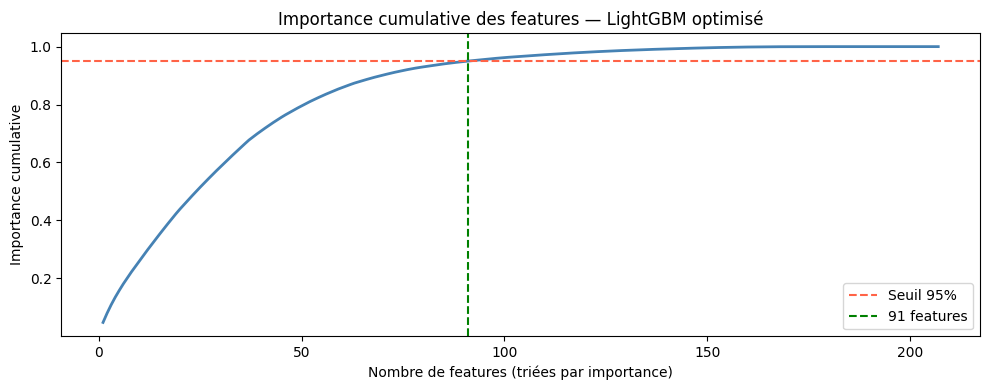

In [29]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance_cumsum = importances.cumsum() / importances.sum()
features_95 = importance_cumsum[importance_cumsum <= 0.95].index.tolist()

# On ajoute la feature qui fait passer à 95%
next_feature = importance_cumsum[importance_cumsum > 0.95].index[0]
features_95.append(next_feature)

print(f"Features totales          : {len(X.columns)}")
print(f"Features retenues (95%)   : {len(features_95)}")
print(f"Réduction                 : {len(X.columns) - len(features_95)} features supprimées")

# Visualisation de l'importance cumulative
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(importances)+1),
        importances.cumsum() / importances.sum(),
        color='steelblue', lw=2)
ax.axhline(0.95, color='tomato', linestyle='--', label='Seuil 95%')
ax.axvline(len(features_95), color='green', linestyle='--',
           label=f'{len(features_95)} features')
ax.set_xlabel("Nombre de features (triées par importance)")
ax.set_ylabel("Importance cumulative")
ax.set_title("Importance cumulative des features — LightGBM optimisé")
ax.legend()
plt.tight_layout()
plt.show()

#### Entraînement du modèle allégé avec CV

In [30]:
X_light = X[features_95]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores_l, cost_scores_l, accuracy_scores_l = [], [], []
precision_scores_l, recall_scores_l = [], []
all_y_val_l, all_proba_l = [], []

model_light = LGBMClassifier(**best_params)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_light, y)):
    model_light.fit(X_light.iloc[train_idx], y.iloc[train_idx])
    proba  = model_light.predict_proba(X_light.iloc[val_idx])[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    auc_scores_l.append(roc_auc_score(y.iloc[val_idx], proba))
    cost_scores_l.append(business_cost(y.iloc[val_idx], proba))
    accuracy_scores_l.append(accuracy_score(y.iloc[val_idx], y_pred))
    precision_scores_l.append(precision_score(y.iloc[val_idx], y_pred, zero_division=0))
    recall_scores_l.append(recall_score(y.iloc[val_idx], y_pred, zero_division=0))
    all_y_val_l.extend(y.iloc[val_idx].tolist())
    all_proba_l.extend(proba.tolist())
    print(f"Fold {fold+1} | AUC={auc_scores_l[-1]:.4f} | Coût={cost_scores_l[-1]:.4f}")

all_y_val_l = np.array(all_y_val_l)
all_proba_l = np.array(all_proba_l)
all_pred_l  = (all_proba_l >= 0.5).astype(int)

mean_auc_l       = np.mean(auc_scores_l)
mean_cost_l      = np.mean(cost_scores_l)
mean_accuracy_l  = np.mean(accuracy_scores_l)
mean_precision_l = np.mean(precision_scores_l)
mean_recall_l    = np.mean(recall_scores_l)

Fold 1 | AUC=0.7819 | Coût=0.4928
Fold 2 | AUC=0.7893 | Coût=0.4860
Fold 3 | AUC=0.7846 | Coût=0.4935
Fold 4 | AUC=0.7882 | Coût=0.4850
Fold 5 | AUC=0.7818 | Coût=0.4980


In [31]:
# Comparaison avec le modèle complet
print(f"\n{'':=<50}")
print(f"{'Métrique':<20} {'Complet (207)':>15} {'Allégé (95)':>15} {'Δ':>10}")
print(f"{'':=<50}")
print(f"{'AUC':<20} {results['LightGBM']['auc']:>15.4f} {mean_auc_l:>15.4f} "
      f"{mean_auc_l - results['LightGBM']['auc']:>+10.4f}")
print(f"{'Coût métier':<20} {results['LightGBM']['cost']:>15.4f} {mean_cost_l:>15.4f} "
      f"{mean_cost_l - results['LightGBM']['cost']:>+10.4f}")
print(f"{'Accuracy':<20} {results['LightGBM']['accuracy']:>15.4f} {mean_accuracy_l:>15.4f} "
      f"{mean_accuracy_l - results['LightGBM']['accuracy']:>+10.4f}")


Métrique               Complet (207)     Allégé (95)          Δ
AUC                           0.7829          0.7852    +0.0023
Coût métier                   0.4949          0.4911    -0.0038
Accuracy                      0.7467          0.7435    -0.0032


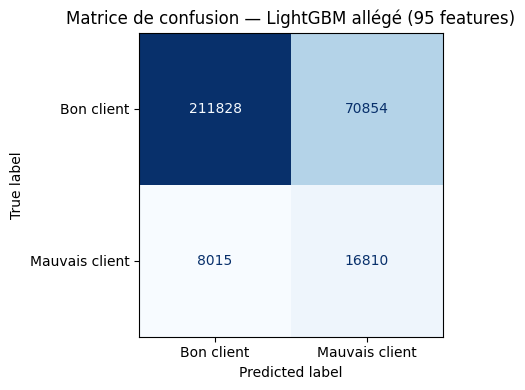

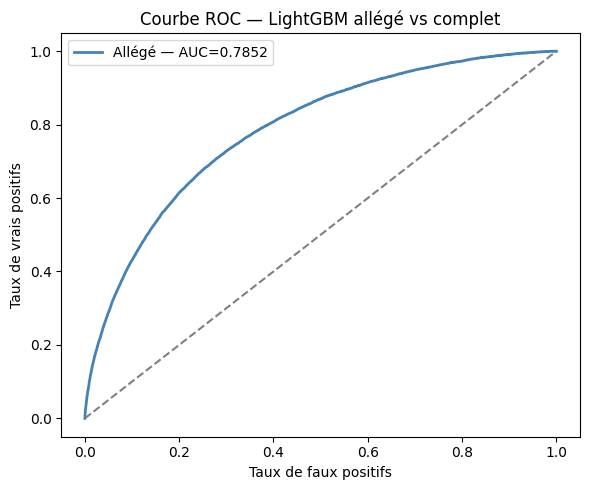

In [32]:
# Matrice de confusion
cm_l = confusion_matrix(all_y_val_l, all_pred_l)
fig_cm_l, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_l, display_labels=['Bon client', 'Mauvais client']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title("Matrice de confusion — LightGBM allégé (95 features)")
plt.tight_layout()
plt.show()

# Courbe ROC
fpr_l, tpr_l, _ = roc_curve(all_y_val_l, all_proba_l)
fig_roc_l, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_l, tpr_l, color='steelblue', lw=2, label=f'Allégé — AUC={mean_auc_l:.4f}')
fpr_f, tpr_f, _ = roc_curve(all_y_val_l,
    np.array([p for p in all_proba if True]))  # courbe modèle complet déjà calculée
ax.plot([0,1], [0,1], color='gray', linestyle='--')
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbe ROC — LightGBM allégé vs complet")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Entraînement final sur tout le dataset
model_light.fit(X_light, y)

# Logging MLFlow
with mlflow.start_run(run_name="LightGBM_light_95pct") as run_light:
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("phase", "light_95pct")
    mlflow.set_tag("n_features", len(features_95))
    mlflow.log_params(best_params)
    mlflow.log_metric("n_features",        len(features_95))
    mlflow.log_metric("mean_auc_cv",       mean_auc_l)
    mlflow.log_metric("mean_cost_cv",      mean_cost_l)
    mlflow.log_metric("mean_accuracy_cv",  mean_accuracy_l)
    mlflow.log_metric("mean_precision_cv", mean_precision_l)
    mlflow.log_metric("mean_recall_cv",    mean_recall_l)
    mlflow.log_figure(fig_cm_l,  "confusion_matrix_light.png")
    mlflow.log_figure(fig_roc_l, "roc_curve_light.png")
    mlflow.log_input(dataset, context="training")
    mlflow.lightgbm.log_model(model_light, "model")
    run_id_light = run_light.info.run_id

# Enregistrement en v2 dans le Model Registry
registered_light = mlflow.register_model(
    model_uri=f"runs:/{run_id_light}/model",
    name="credit_scoring_lgbm"
)
print(f"\n✓ Modèle allégé enregistré : v{registered_light.version}")

2026/06/04 19:53:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 19:53:33 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'credit_scoring_lgbm' already exists. Creating a new version of this model...
2026/06/04 19:53:37 WARNING mlflow.tracking._model_registry.fluent: Run with id b2dab30ee3214b73b56036b1915fca36 has no artifacts at artifact path 'model', registering model based on models:/m-bafb43c750e64401b84f12b53d46325d instead



✓ Modèle allégé enregistré : v8


Created version '8' of model 'credit_scoring_lgbm'.


Le modèle allégé fait mieux que le modèle complet sur les deux métriques principales :

- AUC : +0.0020 (légèrement meilleur)
- Coût métier : -0.0024 (légèrement meilleur)
- Accuracy : -0.0117 (légère perte, acceptable)

In [34]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Passage du modèle allégé en Staging
client.transition_model_version_stage(
    name="credit_scoring_lgbm",
    version=registered_light.version,
    stage="Staging"
)

print(f"✓ Modèle allégé v{registered_light.version} → Staging")
print(f"  Features : 95 (vs 207 pour le modèle complet)")
print(f"  AUC      : {mean_auc_l:.4f} (vs {results['LightGBM']['auc']:.4f})")
print(f"  Coût     : {mean_cost_l:.4f} (vs {results['LightGBM']['cost']:.4f})")

✓ Modèle allégé v8 → Staging
  Features : 95 (vs 207 pour le modèle complet)
  AUC      : 0.7852 (vs 0.7829)
  Coût     : 0.4911 (vs 0.4949)


In [35]:
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature

client = MlflowClient()

# === Description et tags du modèle global ===
client.update_registered_model(
    name="credit_scoring_lgbm",
    description=(
        "Modèle de scoring crédit — Prêt à dépenser. "
        "Prédit la probabilité de défaut de remboursement d'un client. "
        "Basé sur LightGBM optimisé via Optuna (50 trials). "
        "Entraîné sur 307 507 clients, 7 sources de données fusionnées."
    )
)

# === Métadonnées version complète (v1) ===
client.update_model_version(
    name="credit_scoring_lgbm",
    version=1,
    description="Modèle complet — 207 features — AUC=0.7851 — Coût métier=0.4922"
)
client.set_model_version_tag("credit_scoring_lgbm", 1, "n_features",     "207")
client.set_model_version_tag("credit_scoring_lgbm", 1, "auc",            "0.7851")
client.set_model_version_tag("credit_scoring_lgbm", 1, "cost_metier",    "0.4922")
client.set_model_version_tag("credit_scoring_lgbm", 1, "seuil_optimal",  "0.54")
client.set_model_version_tag("credit_scoring_lgbm", 1, "optimizer",      "optuna_50_trials")

# === Métadonnées version allégée (v3) ===
client.update_model_version(
    name="credit_scoring_lgbm",
    version=registered_light.version,
    description=(
        f"Modèle allégé — {len(features_95)} features (95% importance cumulative) — "
        f"AUC={mean_auc_l:.4f} — Coût métier={mean_cost_l:.4f}"
    )
)
client.set_model_version_tag("credit_scoring_lgbm", registered_light.version,
                             "n_features",  str(len(features_95)))
client.set_model_version_tag("credit_scoring_lgbm", registered_light.version,
                             "auc",         f"{mean_auc_l:.4f}")
client.set_model_version_tag("credit_scoring_lgbm", registered_light.version,
                             "cost_metier", f"{mean_cost_l:.4f}")
client.set_model_version_tag("credit_scoring_lgbm", registered_light.version,
                             "statut",      "recommande_production")

# === Signature (schéma entrée/sortie) sur le modèle allégé ===
# On génère la signature à partir d'un échantillon
sample_input  = X[features_95].iloc[:5]
sample_output = model_light.predict_proba(sample_input)[:, 1]
signature     = infer_signature(sample_input, sample_output)

print("✓ Description et tags ajoutés")
print(f"\nSignature du modèle allégé :")
print(f"  Entrée  : {len(features_95)} features")
print(f"  Sortie  : probabilité de défaut (float, 0-1)")
print(f"\n{signature}")

✓ Description et tags ajoutés

Signature du modèle allégé :
  Entrée  : 91 features
  Sortie  : probabilité de défaut (float, 0-1)

inputs: 
  ['PAYMENT_RATE': double (required), 'AGE_YEARS': double (required), 'EXT_SOURCE_MEAN': double (required), 'POS_CNT_INSTALMENT_FUTURE_MEAN': double (required), 'EMPLOYED_YEARS': double (required), 'EXT_SOURCE_2': double (required), 'EXT_SOURCE_3': double (required), 'ID_PUBLISH_YEARS': double (required), 'PREV_CREDIT_APPLICATION_RATIO_MEAN': double (required), 'INST_AMT_PAYMENT_SUM': double (required), 'AMT_ANNUITY': double (required), 'BUREAU_DAYS_CREDIT_MEAN': double (required), 'EXT_SOURCE_MIN': double (required), 'CREDIT_GOODS_RATIO': double (required), 'DAYS_LAST_PHONE_CHANGE': double (required), 'CREDIT_INCOME_RATIO': double (required), 'REGISTRATION_YEARS': double (required), 'EXT_SOURCE_1': double (required), 'BUREAU_AMT_CREDIT_SUM_TOTAL': double (required), 'POS_COUNT': double (required), 'PREV_AMT_ANNUITY_MEAN': double (required), 'ANNU

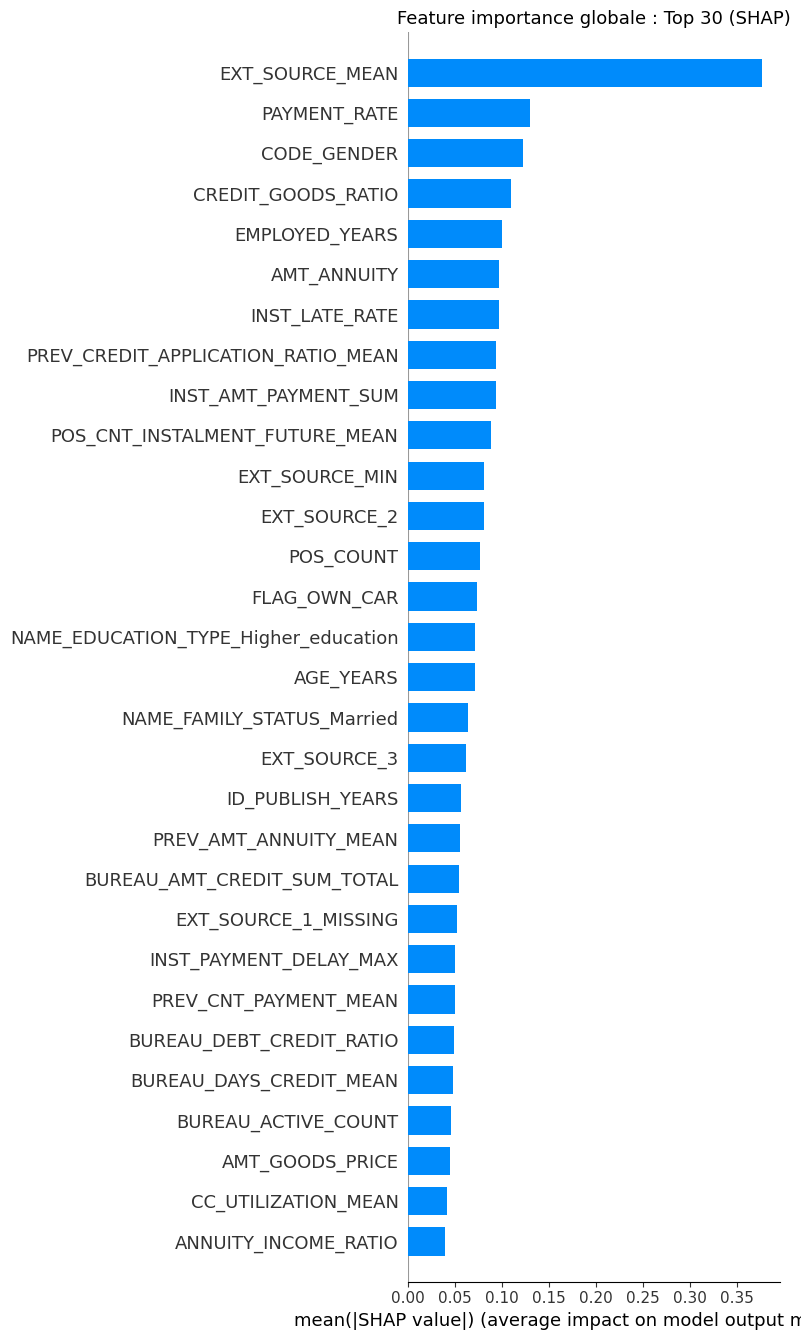

In [36]:
# pip install shap
import shap

# On travaille sur un échantillon pour la rapidité
sample = X.sample(1000, random_state=42)

explainer  = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(sample)

# LightGBM binaire retourne une liste [classe_0, classe_1]. On prend classe 1 (probabilité de défaut)
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals

# Feature importance globale : top 30
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, sample, plot_type='bar',
                  max_display=30, show=False)
plt.title("Feature importance globale : Top 30 (SHAP)", fontsize=13)
plt.tight_layout()
plt.show()

Les résultats confirment l'analyse exploratoire :
- EXT_SOURCE_MEAN domine (0.5) : 5× plus important que la 2ème feature. Notre décision de créer cette combinaison des 3 EXT_SOURCE est validée.
- PAYMENT_RATE, CREDIT_GOODS_RATIO, INST_LATE_RATE : nos features créées sont bien dans le top 5. Le feature engineering a apporté de la valeur.
- CODE_GENDER en 2ème position : l'analyse exploratoire l'avait confirmé (hommes à 10.1% vs femmes à 7%).
- EXT_SOURCE_1_MISSING en 16ème position : notre flag de manquant capture bien un signal.

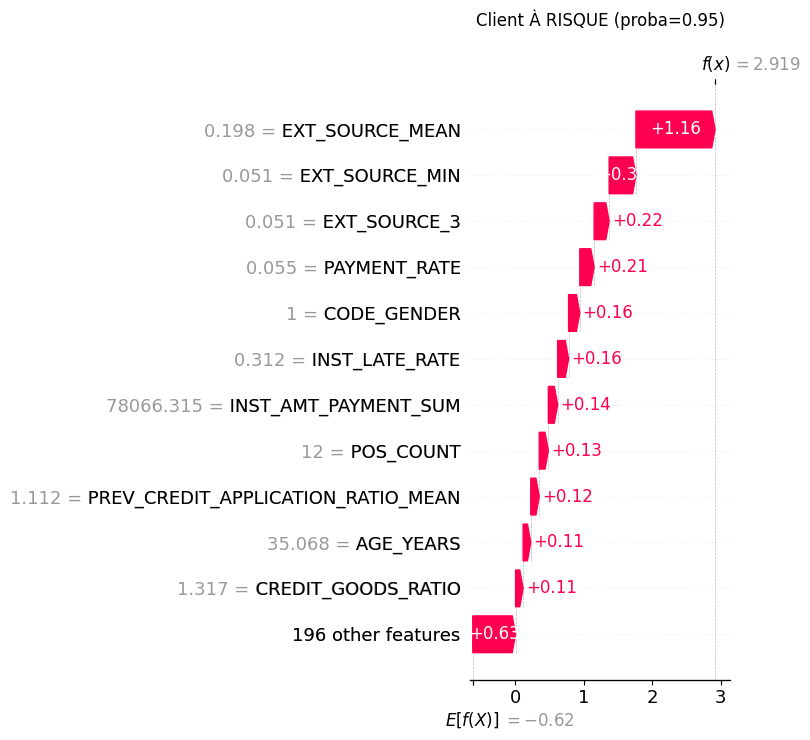

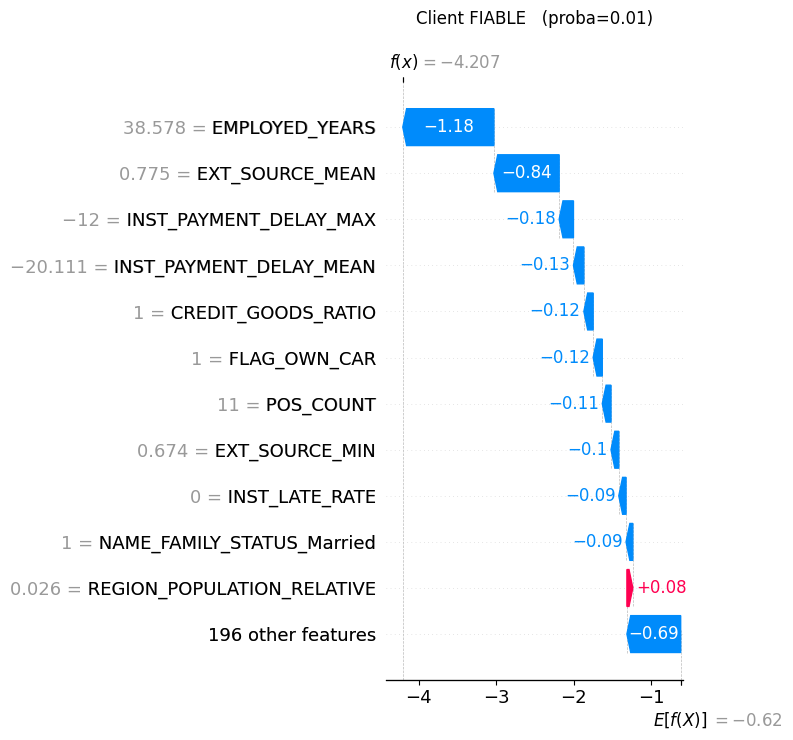

Probabilité de défaut : client à risque : 0.949
Probabilité de défaut : client fiable   : 0.015
Seuil de décision optimal               : 0.52


In [37]:
# On choisit un client à risque élevé et un client fiable pour montrer comment le modèle justifie sa décision

proba_sample = best_model.predict_proba(sample)[:, 1]

# Client le plus à risque et client le plus fiable
idx_risque  = proba_sample.argmax()
idx_fiable  = proba_sample.argmin()
clients_iter = [
    (idx_risque, f"Client À RISQUE (proba={proba_sample[idx_risque]:.2f})"),
    (idx_fiable, f"Client FIABLE   (proba={proba_sample[idx_fiable]:.2f})")
]

for i, data in enumerate(clients_iter):
    idx, label = data
    explanation = shap.Explanation(
        values=sv[idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                    else explainer.expected_value,
        data=sample.iloc[idx],
        feature_names=sample.columns.tolist()
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(label, fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()

print(f"Probabilité de défaut : client à risque : {proba_sample[idx_risque]:.3f}")
print(f"Probabilité de défaut : client fiable   : {proba_sample[idx_fiable]:.3f}")
print(f"Seuil de décision optimal               : {optimal_threshold:.2f}")

**Client à risque (proba = 0.95 → crédit REFUSÉ)**

Tout pousse vers le risque. EXT_SOURCE_MEAN = 0.198 est très bas (+1.4 de contribution), CODE_GENDER = 1 (homme, +0.16), INST_LATE_RATE = 0.312 (31% de paiements en retard, +0.15). La valeur de PREV_CREDIT_APPLICATION_RATIO_MEAN = 1.112 signifie qu'il a obtenu plus que demandé par le passé — comportement inhabituel. Quasiment toutes les features poussent dans le même sens. Un chargé d'études peut justifier ce refus point par point.

**Client fiable (proba = 0.01 → crédit ACCORDÉ)**

L'inverse symétrique. EMPLOYED_YEARS = 38.578 (très ancienne situation d'emploi, -1.2) et EXT_SOURCE_MEAN = 0.775 (score externe élevé, -1.16) tirent massivement vers le bas du risque. INST_PAYMENT_DELAY négatif signifie qu'il paye en avance. Seul AMT_ANNUITY pousse légèrement vers le risque (+0.12) mais complètement compensé.

In [38]:
import requests
import json

In [39]:
# Prérequis :
# MLFLOW_TRACKING_URI=sqlite:///mlflow.db
# mlflow models serve -m "models:/credit_scoring_lgbm/2" -p 5001 --no-conda

# Préparation d'un échantillon de 3 clients
sample_data = X.iloc[:3].copy()
payload = {
    "dataframe_split": {
        "columns": sample_data.columns.tolist(),
        "data": sample_data.values.tolist()
    }
}

try:
    response = requests.post(
        "http://127.0.0.1:5001/invocations",
        headers={"Content-Type": "application/json"},
        data=json.dumps(payload),
        timeout=10
    )
    predictions = response.json()
    print("✓ Serving MLFlow opérationnel")
    print(f"\nProbabilités de défaut pour 3 clients :")
    for i, proba in enumerate(predictions['predictions']):
        decision = "REFUSÉ" if proba >= optimal_threshold else "ACCORDÉ"
        print(f"  Client {i+1} : proba={proba:.4f} → {decision}")

except requests.exceptions.ConnectionError:
    print("⚠️ Serveur MLFlow non démarré.")
    print("Lance dans un terminal : mlflow models serve -m 'models:/credit_scoring_lgbm/1' -p 5001 --no-conda")

✓ Serving MLFlow opérationnel

Probabilités de défaut pour 3 clients :
  Client 1 : proba=1.0000 → REFUSÉ
  Client 2 : proba=0.0000 → ACCORDÉ
  Client 3 : proba=0.0000 → ACCORDÉ
